# 14 — Replicated isolated scale shift

This developmental experiment fits RNN and CA-RNN on each of 50 independent Gaussian autoregressive datasets. For each realization the models are frozen, and only post-split innovation scale changes at severities 0, 0.5, and 1.0. Correlation, mean dynamics, and innovation family remain fixed. One neural seed is assigned to each DGP realization; thus Monte Carlo uncertainty combines DGP and optimization variability and cannot separate them. Results are not part of the frozen external-panel protocol.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from innovcal.ca_rnn import TrainingConfig
from innovcal.experiments import IsolatedScaleShiftConfig, run_isolated_scale_shift, summarize_isolated_shift

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT = ROOT / 'results' / 'isolated_scale_shift'
OUT.mkdir(parents=True, exist_ok=True)
CONFIG = IsolatedScaleShiftConfig(dgp_seeds=tuple(range(1000, 1050)))
TRAINING = TrainingConfig(epochs=120, batch_size=64, patience=15, selection_metric='nll')
RAW_PATH = OUT / 'replication_metrics.csv'
print('Independent DGP realizations:', len(CONFIG.dgp_seeds), 'fits:', 2 * len(CONFIG.dgp_seeds))

Independent DGP realizations: 50 fits: 100


## Fit once per realization

This is the expensive cell (100 neural fits). It checkpoints after each complete DGP realization, so an interrupted run can resume without refitting completed realizations. Do not change settings after the first checkpoint; use a new output path for a changed design. Failed fits remain visible in the raw table.

In [2]:
raw = run_isolated_scale_shift(CONFIG, TRAINING, checkpoint_path=RAW_PATH)
print(raw.groupby(['model', 'severity']).agg(rows=('realization', 'size'), failures=('failure', lambda s: (s != '').sum())))
display(raw.head())

                 rows  failures
model  severity                
CA-RNN 0.0         50         0
       0.5         50         0
       1.0         50         0
RNN    0.0         50         0
       0.5         50         0
       1.0         50         0


,realization,dgp_seed,neural_seed,model,severity,failure,training_seconds,best_epoch,test_nll,analytic_pit_calibration_error,...,variogram_score,coverage,interval_width,interval_score,pit_calibration_error,pit_mean_absolute_autocorrelation,pit_mean_ks,coordinate_pit_calibration_error,coordinate_pit_mean_absolute_autocorrelation,coordinate_pit_mean_ks
0,0,1000,606,RNN,0.0,,1.975723,13,5.427811,0.000442,...,0.143286,0.885417,3.176079,4.016872,0.000441,0.069874,0.051600,0.000467,0.067789,0.049620
1,0,1000,606,RNN,0.5,,1.975723,13,8.092756,0.006061,...,0.261020,0.713542,3.184979,7.434207,0.005911,0.068228,0.128302,0.005519,0.067076,0.120902
2,0,1000,606,RNN,1.0,,1.975723,13,11.890759,0.014431,...,0.433142,0.578125,3.198693,12.569289,0.014290,0.067186,0.188687,0.013546,0.069300,0.181063
3,0,1000,606,CA-RNN,0.0,,0.842510,11,5.431967,0.000436,...,0.143073,0.907292,3.359575,4.004339,0.000443,0.069337,0.050313,0.000446,0.067402,0.045110
4,0,1000,606,CA-RNN,0.5,,0.842510,11,7.867485,0.004695,...,0.252626,0.734375,3.368142,7.104974,0.004619,0.065903,0.117304,0.004326,0.062591,0.109425


In [3]:
summary = summarize_isolated_shift(raw)
summary.to_csv(OUT / 'paired_mc_summary.csv', index=False)
display(summary)
print('Negative CA-RNN minus RNN differences favor CA-RNN for loss metrics.')

,severity,metric,n_valid_pairs,n_dgp_realizations,failure_frequency,mean_paired_difference,mc_standard_error,mean_rnn,mean_ca_rnn
0,0.0,test_nll,50,50,0.0,0.006287,0.002765,5.412690,5.418976
1,0.0,mean_squared_error,50,50,0.0,-0.001659,0.001276,0.965864,0.964204
2,0.0,energy_score,50,50,0.0,-0.000109,0.000794,1.291229,1.291119
3,0.0,variogram_score,50,50,0.0,0.000414,0.000107,0.141451,0.141865
4,0.0,interval_score,50,50,0.0,0.003105,0.004350,4.087492,4.090598
5,0.0,analytic_pit_calibration_error,50,50,0.0,-0.000025,0.000024,0.000907,0.000882
6,0.0,analytic_pit_mean_absolute_autocorrelation,50,50,0.0,-0.001667,0.000667,0.063815,0.062148
7,0.5,test_nll,50,50,0.0,-0.225055,0.015342,8.109986,7.884931
8,0.5,mean_squared_error,50,50,0.0,-0.006438,0.002601,2.171716,2.165278
9,0.5,energy_score,50,50,0.0,-0.016235,0.001520,2.005415,1.989180


Negative CA-RNN minus RNN differences favor CA-RNN for loss metrics.


In [4]:
subset_sizes = [10, 25, len(CONFIG.dgp_seeds)]
sensitivity = pd.concat([
    summarize_isolated_shift(raw.loc[raw.realization < count]).assign(replications_included=count)
    for count in subset_sizes
])
sensitivity.to_csv(OUT / 'mc_replication_sensitivity.csv', index=False)
display(sensitivity.loc[sensitivity.metric.isin(['energy_score', 'variogram_score', 'analytic_pit_calibration_error'])])

,severity,metric,n_valid_pairs,n_dgp_realizations,failure_frequency,mean_paired_difference,mc_standard_error,mean_rnn,mean_ca_rnn,replications_included
2,0.0,energy_score,10,10,0.0,-0.002021,0.001087,1.293709,1.291688,10
3,0.0,variogram_score,10,10,0.0,0.000482,0.000231,0.141452,0.141934,10
5,0.0,analytic_pit_calibration_error,10,10,0.0,-0.000083,0.000059,0.000937,0.000854,10
9,0.5,energy_score,10,10,0.0,-0.020644,0.001690,2.008791,1.988147,10
10,0.5,variogram_score,10,10,0.0,-0.008462,0.000515,0.252667,0.244204,10
12,0.5,analytic_pit_calibration_error,10,10,0.0,-0.001475,0.000072,0.006262,0.004787,10
16,1.0,energy_score,10,10,0.0,-0.035270,0.002602,2.807381,2.772111,10
17,1.0,variogram_score,10,10,0.0,-0.017142,0.001041,0.418276,0.401134,10
19,1.0,analytic_pit_calibration_error,10,10,0.0,-0.002037,0.000103,0.014569,0.012532,10
2,0.0,energy_score,25,25,0.0,0.000534,0.001275,1.293694,1.294228,25


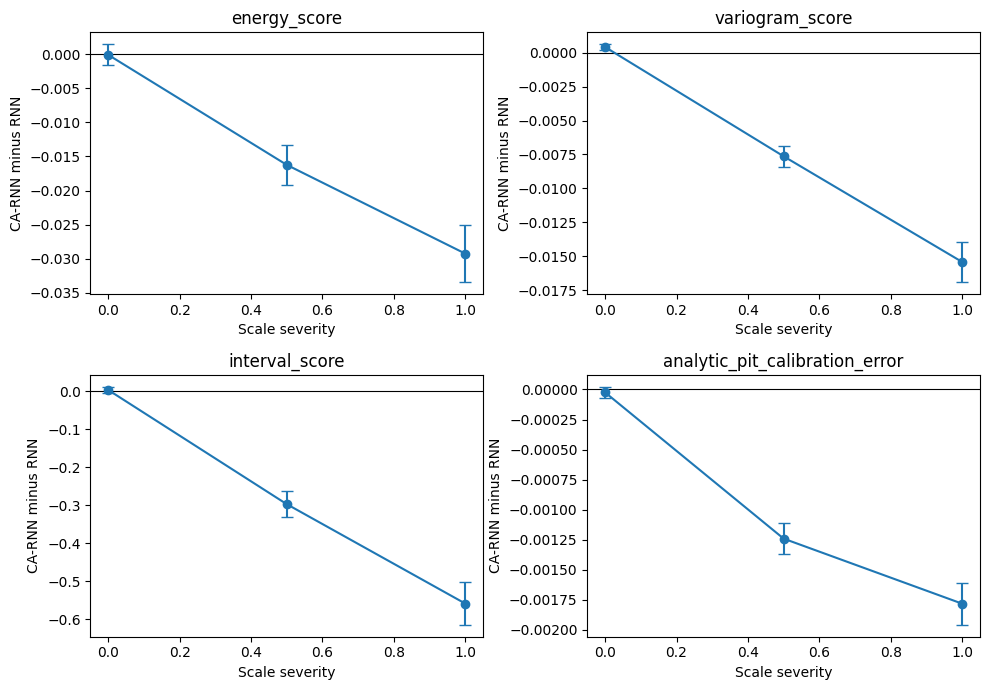

In [5]:
selected = ['energy_score', 'variogram_score', 'interval_score', 'analytic_pit_calibration_error']
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for axis, metric in zip(axes.flat, selected):
    frame = summary.loc[summary.metric.eq(metric)].sort_values('severity')
    axis.errorbar(frame.severity, frame.mean_paired_difference, yerr=1.96 * frame.mc_standard_error, marker='o', capsize=4)
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set_title(metric)
    axis.set_xlabel('Scale severity')
    axis.set_ylabel('CA-RNN minus RNN')
fig.tight_layout()
fig.savefig(OUT / 'paired_shift_profiles.png', dpi=180)
plt.show()

Interpret only effects stable across independent realizations and the replication-count check. The plotted ±1.96 MCSE bars summarize Monte Carlo precision, not uncertainty over alternative DGP families or hyperparameter choices. The old notebook 05 changes scale and correlation together and remains exploratory.